# Garmin Running Activity Analysis

Analyze and visualize running metrics pulled from a local SQLite database of Garmin Connect activities.

**What this notebook covers:**
- Time-series plots of 8 key running metrics (distance, pace, duration, elevation, heart rate, calories, cadence)
- Personal records across all tracked metrics
- Weekly and monthly summaries for trend analysis

> Data is loaded via the `garmin-activity-puller` CLI tool. See the [README](../README.md) for setup instructions.

## Setup & Data Loading
Import helper modules and load all running activities from the SQLite database into a pandas DataFrame.

In [1]:
import sys
sys.path.insert(0, "..")

from src.db import load_dataframe
from src.stats import weekly_summary, monthly_summary, personal_records

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df = load_dataframe()
print(f"Loaded {len(df)} activities")
df.head()

Filtered 90 bad records (1251 clean activities)
Loaded 1251 activities


,activity_id,name,start_time,distance_m,duration_s,calories,avg_hr,max_hr,avg_speed,elevation_gain,cadence,distance_km,duration_min,pace_min_km
0,1478566037,Frederiksværk Løb,2016-12-10 15:04:15,15077.98,3955.863,910.019523,167.0,183.0,3.812000,79.0,173.562500,15.07798,65.931050,4.372671
1,1481249646,Frederiksberg C Løb,2016-12-12 17:02:08,2252.25,672.799,146.061355,142.0,155.0,3.348000,4.0,169.093750,2.25225,11.213317,4.978718
2,1481249857,5 km Fælledparken,2016-12-12 17:15:00,5000.00,1155.000,337.945881,175.0,185.0,4.329004,6.0,177.390625,5.00000,19.250000,3.850000
3,1481249977,København K Løb,2016-12-12 17:36:52,2590.26,809.849,182.099369,146.0,159.0,3.198000,4.0,162.703125,2.59026,13.497483,5.210860
4,1483403196,København K Løb,2016-12-14 14:30:04,11229.29,3020.274,710.975127,152.0,177.0,3.718000,39.0,173.203125,11.22929,50.337900,4.482732


## Metrics Over Time
Plot each key running metric as a time-series to visualize trends and spot patterns across training sessions.

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle("Running Metrics Over Time", fontsize=16, fontweight="bold")

date_fmt = mdates.DateFormatter("%b '%y")
ROLLING_WINDOW = 20  # 20-run rolling average

metrics = [
    ("distance_km", "Distance (km)", "#2196F3"),
    ("pace_min_km", "Pace (min/km)", "#FF5722"),
    ("duration_min", "Duration (min)", "#4CAF50"),
    ("elevation_gain", "Elevation Gain (m)", "#795548"),
    ("avg_hr", "Avg Heart Rate (bpm)", "#E91E63"),
    ("max_hr", "Max Heart Rate (bpm)", "#9C27B0"),
    ("calories", "Calories (kcal)", "#FF9800"),
    ("cadence", "Cadence (spm)", "#607D8B"),
]

for ax, (col, label, color) in zip(axes.flat, metrics):
    data = df.dropna(subset=[col]).sort_values("start_time")
    # Raw data as faint dots
    ax.scatter(data["start_time"], data[col], color=color, alpha=0.15, s=10, zorder=1)
    # Rolling average as bold line
    rolling = data.set_index("start_time")[col].rolling(f"{ROLLING_WINDOW * 3}D", min_periods=5).mean()
    ax.plot(rolling.index, rolling.values, color=color, linewidth=2.5, zorder=2,
            label=f"{ROLLING_WINDOW}-run avg")
    ax.set_ylabel(label)
    ax.xaxis.set_major_formatter(date_fmt)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.2)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.7)

plt.tight_layout()
plt.show()

## Summary Stats
Personal records and monthly aggregates — distance, duration, and activity count rolled up by month.

In [3]:
print("Personal Records")
prs = personal_records(df)
for key, val in prs.items():
    print(f"  {key}: {val['value']}  ({val['date']})")

print("\nMonthly Summary")
monthly_summary(df)

Personal Records
  fastest_pace: 3:15 min/km  (Aug 12, 2021)
  longest_run: 40.80 km  (Jun 06, 2021)
  most_elevation: +794 m  (Jun 06, 2021)

Monthly Summary


,runs,total_km,total_min,avg_pace,avg_cadence,avg_hr,total_elevation,total_calories
month,,,,,,,,
2016-12,25,140.1,655.2,4.8,167.5,154.5,585.0,9460.1
2017-01,31,217.7,1024.9,4.8,166.0,150.5,559.0,14797.1
2017-02,18,118.8,588.1,5.1,156.3,154.4,300.0,8549.0
2017-03,11,72.6,327.2,4.8,166.2,154.0,151.0,5186.0
2017-04,2,16.0,72.4,4.5,170.7,165.0,82.0,1203.0
...,...,...,...,...,...,...,...,...
2025-09,6,67.5,320.2,4.8,165.1,NaN,308.0,5663.0
2025-10,2,26.4,122.9,4.7,167.0,NaN,103.0,2238.0
2025-12,2,27.5,137.5,5.0,166.0,NaN,117.0,2319.0


### Weekly Breakdown
Week-over-week totals for distance, duration, and activity count.

In [4]:
print("Weekly Summary")
weekly_summary(df)

Weekly Summary


,runs,total_km,total_min,avg_pace,avg_cadence,avg_hr,total_elevation,total_calories
year_week,,,,,,,,
2016-W49,1,15.1,65.9,4.4,173.6,167.0,79.0,910.0
2016-W50,7,46.2,211.4,4.6,171.0,152.9,95.0,2989.0
2016-W51,4,17.9,81.8,4.7,170.9,156.8,61.0,1298.1
2016-W52,13,60.9,296.1,5.0,164.0,153.8,350.0,4263.0
2017-W01,6,61.8,277.1,4.6,171.9,154.7,166.0,4013.8
...,...,...,...,...,...,...,...,...
2026-W01,2,25.5,135.3,5.3,163.2,NaN,114.0,2146.0
2026-W02,3,26.8,136.5,5.3,163.5,NaN,76.0,2257.0
2026-W03,1,12.0,62.2,5.2,165.7,NaN,46.0,1020.0


### Monthly Distance
Bar chart of total kilometers per month — quickly spot training blocks, injuries, and seasonal patterns.

In [ ]:
# Monthly total distance bar chart
monthly = df.set_index("start_time").resample("MS")["distance_km"].sum()

fig, ax = plt.subplots(figsize=(14, 5))

# Color bars by volume: lighter for low months, darker for high
norm = plt.Normalize(monthly.min(), monthly.max())
colors = plt.cm.Blues(norm(monthly.values) * 0.7 + 0.3)

ax.bar(monthly.index, monthly.values, width=25, color=colors, edgecolor="white", linewidth=0.5)

# 3-month rolling average trend line
rolling_3m = monthly.rolling(3, min_periods=1).mean()
ax.plot(rolling_3m.index, rolling_3m.values, color="#FF5722", linewidth=2.5,
        label="3-month rolling avg", zorder=3)

# Yearly average reference line
yearly_avg = monthly.mean()
ax.axhline(yearly_avg, color="#999", linestyle="--", alpha=0.5,
           label=f"Overall avg: {yearly_avg:.0f} km/mo")

ax.set_ylabel("Total km")
ax.set_title("Monthly Running Distance", fontsize=13, fontweight="bold", pad=15)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.tick_params(axis="x", rotation=45)
ax.legend(loc="upper left", framealpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Pace Zone Distribution

Classify each run by average pace into personal training zones.

| Zone | Pace (min/km) | Purpose |
|------|--------------|---------|
| Recovery | > 5:25 | Easy recovery, warm-up/cool-down |
| Easy | 4:35 – 5:25 | Base building, fat burning |
| Tempo | 4:00 – 4:35 | Lactate threshold, sustained effort |
| Threshold | 3:20 – 4:00 | Race pace, VO2 improvement |
| Speed | < 3:20 | Intervals, sprints, max effort |

In [5]:
import numpy as np
import pandas as pd

# Personal pace zones (min/km boundaries)
# 3:20 = 3.333, 4:00 = 4.0, 4:35 = 4.583, 5:25 = 5.417
zone_bins = [0, 3.333, 4.0, 4.583, 5.417, np.inf]
zone_labels = ["Speed", "Threshold", "Tempo", "Easy", "Recovery"]
zone_colors = ["#e53935", "#ff9800", "#fdd835", "#42a5f5", "#ab47bc"]

# Classify each run
df["pace_zone"] = pd.cut(df["pace_min_km"], bins=zone_bins, labels=zone_labels, right=True)

# Count and percentage per zone
zone_counts = df["pace_zone"].value_counts().reindex(zone_labels)
zone_pct = (zone_counts / zone_counts.sum() * 100).round(1)

print("=== Pace Zone Breakdown ===\n")
for zone, count, pct in zip(zone_labels, zone_counts, zone_pct):
    bar = "█" * int(pct / 2)
    print(f"  {zone:12s}  {count:4.0f} runs  ({pct:5.1f}%)  {bar}")

=== Pace Zone Breakdown ===

  Speed            2 runs  (  0.2%)  
  Threshold       95 runs  (  7.6%)  ███
  Tempo          343 runs  ( 27.4%)  █████████████
  Easy           698 runs  ( 55.8%)  ███████████████████████████
  Recovery       113 runs  (  9.0%)  ████


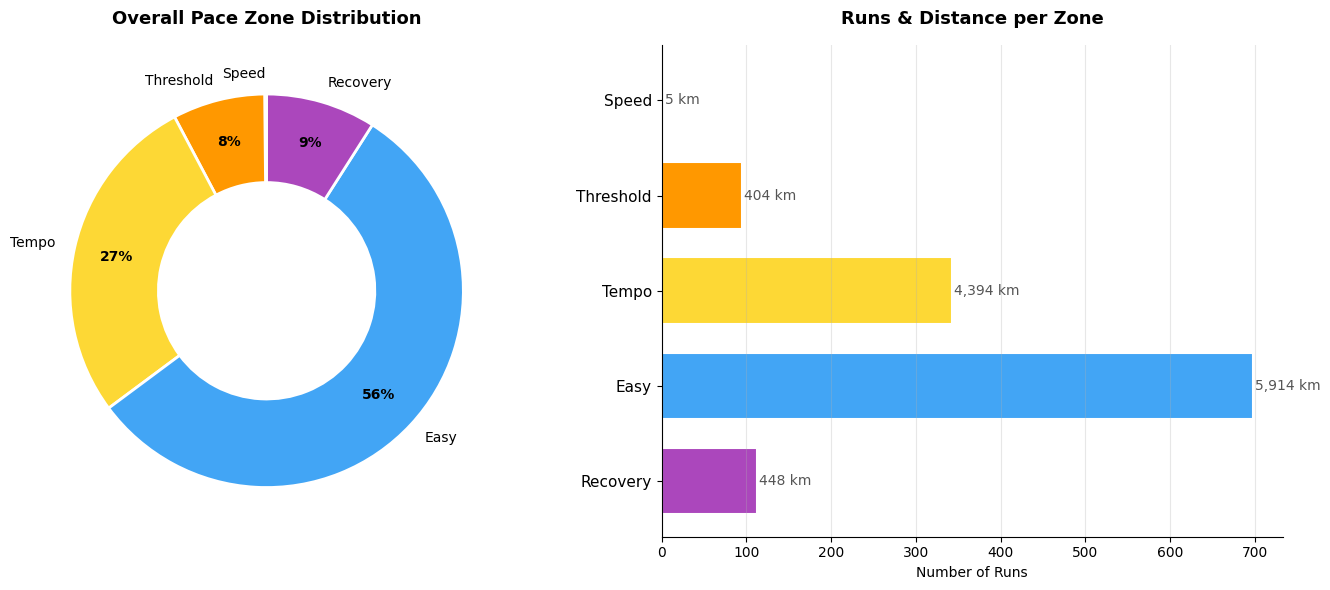

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Donut chart: overall zone distribution ---
wedges, texts, autotexts = ax1.pie(
    zone_counts, labels=zone_labels, colors=zone_colors,
    autopct=lambda p: f"{p:.0f}%" if p > 3 else "",
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2),
)
for t in autotexts:
    t.set_fontsize(10)
    t.set_fontweight("bold")
ax1.set_title("Overall Pace Zone Distribution", fontsize=13, fontweight="bold", pad=15)

# --- Horizontal bar chart: runs per zone with km totals ---
zone_km = df.groupby("pace_zone", observed=True)["distance_km"].sum().reindex(zone_labels)
y_pos = range(len(zone_labels))

bars = ax2.barh(y_pos, zone_counts, color=zone_colors, edgecolor="white", linewidth=1.5, height=0.7)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(zone_labels, fontsize=11)
ax2.set_xlabel("Number of Runs")
ax2.set_title("Runs & Distance per Zone", fontsize=13, fontweight="bold", pad=15)
ax2.invert_yaxis()

# Add km labels on bars
for bar, km in zip(bars, zone_km):
    width = bar.get_width()
    if width > 0:
        ax2.text(width + 2, bar.get_y() + bar.get_height()/2,
                f"{km:,.0f} km", va="center", fontsize=10, color="#555")

ax2.grid(axis="x", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

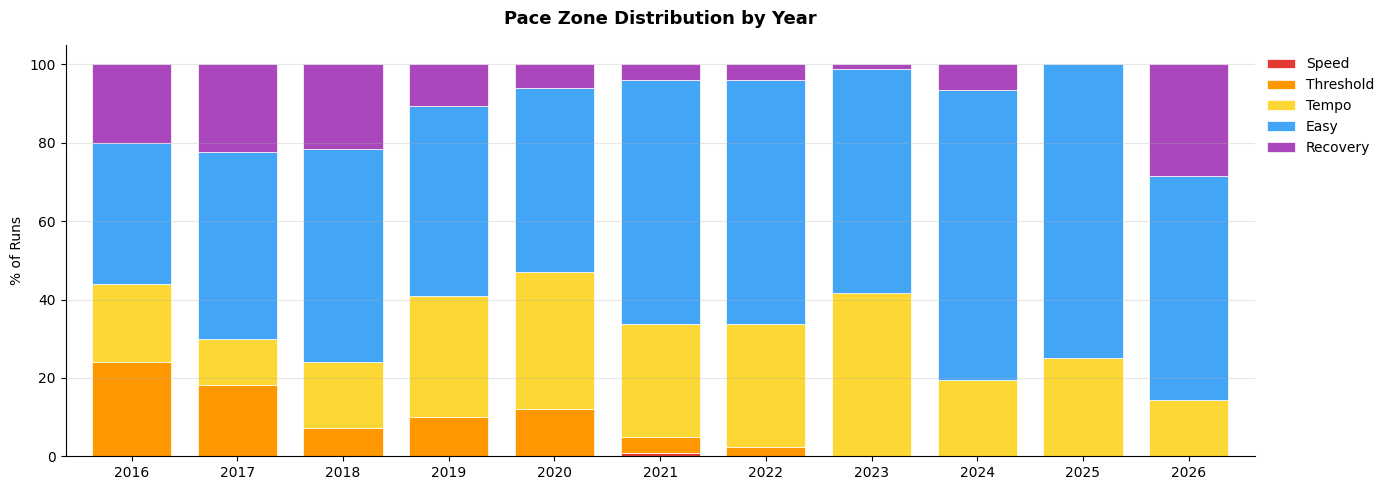

In [7]:
# Pace zone trend by year — stacked bar showing how zone mix shifts over time
import pandas as pd

df["year"] = df["start_time"].dt.year
yearly_zones = df.groupby(["year", "pace_zone"], observed=True).size().unstack(fill_value=0)
yearly_zones = yearly_zones.reindex(columns=zone_labels, fill_value=0)

# Normalize to percentages
yearly_pct = yearly_zones.div(yearly_zones.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 5))
yearly_pct.plot(kind="bar", stacked=True, color=zone_colors, edgecolor="white",
                linewidth=0.5, ax=ax, width=0.75)

ax.set_ylabel("% of Runs")
ax.set_xlabel("")
ax.set_title("Pace Zone Distribution by Year", fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper left", bbox_to_anchor=(1, 1), frameon=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Lap-Level Pace Zone Analysis

The activity-level zones above classify each run by its **overall average pace**, which hides interval work — a 5x1000m session at 3:15/km with recovery jogs averages ~4:15/km and gets classified as "Tempo".

By analysing individual **laps** (11,895 laps pulled from Garmin), we can classify each lap separately and see the true training intensity distribution. Laps also have an `intensity` flag ("ACTIVE" vs "REST") from Garmin.

In [8]:
from src.db import load_laps_dataframe

laps = load_laps_dataframe()
print(f"Loaded {len(laps)} laps across {laps['activity_id'].nunique()} activities")

# Filter out tiny laps (< 100m) that are GPS noise or auto-pause artifacts
laps_clean = laps[(laps["distance_km"] >= 0.1) & (laps["duration_s"] > 0) & (laps["pace_min_km"] >= 1.5) & (laps["pace_min_km"] <= 20)]
print(f"After filtering: {len(laps_clean)} laps ({len(laps) - len(laps_clean)} removed)")

# Classify each lap into pace zones (same bins as activity-level)
laps_clean = laps_clean.copy()
laps_clean["pace_zone"] = pd.cut(laps_clean["pace_min_km"], bins=zone_bins, labels=zone_labels, right=True)

# Breakdown
lap_counts = laps_clean["pace_zone"].value_counts().reindex(zone_labels)
lap_pct = (lap_counts / lap_counts.sum() * 100).round(1)

print(f"\n=== Lap-Level Pace Zone Breakdown ({len(laps_clean)} laps) ===\n")
for zone, count, pct in zip(zone_labels, lap_counts, lap_pct):
    bar = "█" * int(pct / 2)
    print(f"  {zone:12s}  {count:5.0f} laps  ({pct:5.1f}%)  {bar}")

Loaded 12297 laps across 1341 activities
After filtering: 11829 laps (468 removed)

=== Lap-Level Pace Zone Breakdown (11829 laps) ===

  Speed           129 laps  (  1.1%)  
  Threshold      1388 laps  ( 11.7%)  █████
  Tempo          3935 laps  ( 33.3%)  ████████████████
  Easy           5274 laps  ( 44.6%)  ██████████████████████
  Recovery       1103 laps  (  9.3%)  ████


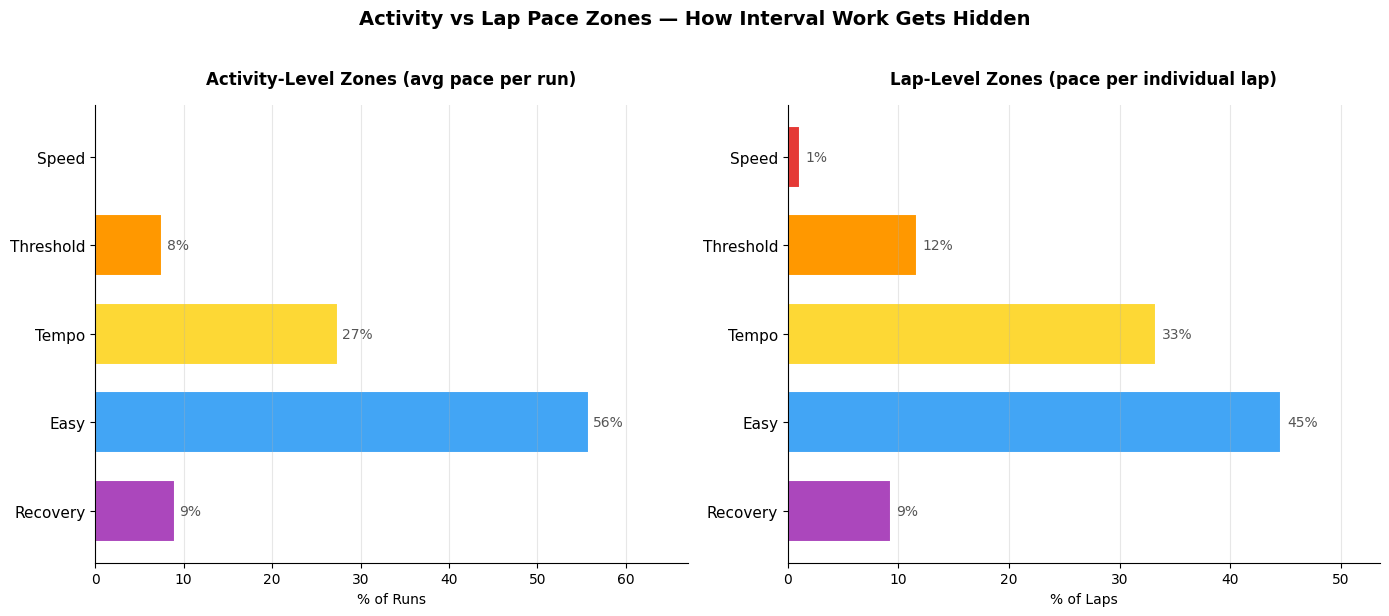

In [9]:
# Side-by-side comparison: Activity-level vs Lap-level zone distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Activity-level (left)
bars1 = ax1.barh(range(len(zone_labels)), zone_pct, color=zone_colors, edgecolor="white", linewidth=1.5, height=0.7)
ax1.set_yticks(range(len(zone_labels)))
ax1.set_yticklabels(zone_labels, fontsize=11)
ax1.set_xlabel("% of Runs")
ax1.set_title("Activity-Level Zones (avg pace per run)", fontsize=12, fontweight="bold", pad=15)
ax1.invert_yaxis()
for bar, pct in zip(bars1, zone_pct):
    if pct > 1:
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{pct:.0f}%", va="center", fontsize=10, color="#555")
ax1.set_xlim(0, max(zone_pct) * 1.2)
ax1.grid(axis="x", alpha=0.3)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Lap-level (right)
bars2 = ax2.barh(range(len(zone_labels)), lap_pct, color=zone_colors, edgecolor="white", linewidth=1.5, height=0.7)
ax2.set_yticks(range(len(zone_labels)))
ax2.set_yticklabels(zone_labels, fontsize=11)
ax2.set_xlabel("% of Laps")
ax2.set_title("Lap-Level Zones (pace per individual lap)", fontsize=12, fontweight="bold", pad=15)
ax2.invert_yaxis()
for bar, pct in zip(bars2, lap_pct):
    if pct > 1:
        ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{pct:.0f}%", va="center", fontsize=10, color="#555")
ax2.set_xlim(0, max(lap_pct) * 1.2)
ax2.grid(axis="x", alpha=0.3)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

plt.suptitle("Activity vs Lap Pace Zones — How Interval Work Gets Hidden", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Pace consistency per activity — which runs had the most pace variation across laps?
# High variation = likely interval sessions
lap_stats = laps_clean.groupby("activity_id").agg(
    name=("name", "first"),
    date=("start_time", "first"),
    num_laps=("lap_index", "count"),
    avg_pace=("pace_min_km", "mean"),
    pace_std=("pace_min_km", "std"),
    fastest_lap=("pace_min_km", "min"),
    slowest_lap=("pace_min_km", "max"),
).dropna(subset=["pace_std"])

lap_stats["pace_spread"] = lap_stats["slowest_lap"] - lap_stats["fastest_lap"]

# Top 15 most variable runs (likely intervals)
print("=== Runs With Most Pace Variation (likely interval sessions) ===\n")
top_variable = lap_stats.nlargest(15, "pace_std")
for _, row in top_variable.iterrows():
    print(f"  {row['date'].strftime('%Y-%m-%d')}  {row['name'][:35]:35s}  "
          f"{row['num_laps']:2.0f} laps  avg {row['avg_pace']:.1f}  "
          f"range {row['fastest_lap']:.1f}–{row['slowest_lap']:.1f} min/km  "
          f"(spread {row['pace_spread']:.1f})")

# Histogram of pace spread
fig, ax = plt.subplots(figsize=(14, 4))
ax.hist(lap_stats["pace_spread"], bins=50, color="#ff9800", alpha=0.7, edgecolor="white")
ax.axvline(lap_stats["pace_spread"].median(), color="black", linestyle="--", alpha=0.5,
           label=f"median: {lap_stats['pace_spread'].median():.1f} min/km")
ax.set_xlabel("Pace Spread (slowest − fastest lap, min/km)")
ax.set_ylabel("Number of Runs")
ax.set_title("Pace Variation Per Run — High Spread = Interval Sessions", fontsize=13, fontweight="bold", pad=15)
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Lap pace histogram — color-coded by zone
fig, ax = plt.subplots(figsize=(14, 5))

for zone, color in zip(zone_labels, zone_colors):
    subset = laps_clean[laps_clean["pace_zone"] == zone]["pace_min_km"]
    if len(subset) > 0:
        ax.hist(subset, bins=40, color=color, alpha=0.7, edgecolor="white", label=zone)

# Zone boundary lines
boundaries = {"3:20": 3.333, "4:00": 4.0, "4:35": 4.583, "5:25": 5.417}
for label, val in boundaries.items():
    ax.axvline(val, color="#333", linestyle="--", alpha=0.4, linewidth=1)
    ax.text(val, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 100,
            f" {label}", fontsize=8, color="#555", va="top")

ax.set_xlabel("Pace (min/km)")
ax.set_ylabel("Number of Laps")
ax.set_title("Lap Pace Distribution (all laps, color-coded by zone)", fontsize=13, fontweight="bold", pad=15)
ax.legend(loc="upper right")
ax.set_xlim(2, 10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()